# Wind Forecast Error Analysis (January 2024)

This notebook analyzes UK national wind generation forecast quality using curated January 2024 Elexon BMRS data (WINDFOR + FUELHH).

## Objective

1. Quantify forecast error behavior for different horizons.
2. Understand when errors are larger (horizon and time-of-day effects).
3. Estimate reliable wind capacity from historical actual generation.

## Method Summary

- For each target timestamp, select the latest forecast published at least `H` hours before target time.
- Constrain forecast-age candidates to the challenge window: age in `[H, 48]` hours.
- If no valid forecast exists for a target timestamp, keep forecast as missing (do not impute).
- Compute error as `forecast - actual` in MW.

## Assumptions and Trade-offs

- January 2024 is treated as representative only for this exercise; seasonality outside January is not captured.
- Missing forecasts are excluded instead of filled to avoid introducing synthetic accuracy.
- Reliability recommendation uses lower-tail percentiles of actual generation (availability-style interpretation),
  which is conservative but easy to communicate to planning stakeholders.

In [4]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [ ]:
data_path = Path('../data/processed/curated_jan2024.json')
payload = json.loads(data_path.read_text(encoding='utf-8'))
df = pd.DataFrame(payload['rows'])

df['targetTime'] = pd.to_datetime(df['targetTime'], utc=True)
df['publishTime'] = pd.to_datetime(df['publishTime'], utc=True, errors='coerce')
df = df.sort_values(['targetTime', 'publishTime'], na_position='last').reset_index(drop=True)
df.head()

,targetTime,publishTime,actualGeneration,forecastGeneration
0,2024-01-01 00:00:00+00:00,2023-12-30 02:30:00+00:00,10402.0,11145.0
1,2024-01-01 00:00:00+00:00,2023-12-30 04:30:00+00:00,10402.0,11141.0
2,2024-01-01 00:00:00+00:00,2023-12-30 07:30:00+00:00,10402.0,10929.0
3,2024-01-01 00:00:00+00:00,2023-12-30 09:30:00+00:00,10402.0,10928.0
4,2024-01-01 00:00:00+00:00,2023-12-30 11:30:00+00:00,10402.0,10915.0


In [6]:
def match_forecast_for_horizon(source: pd.DataFrame, horizon_hours: int, max_age_hours: int = 48) -> pd.DataFrame:
    rows = []
    for target_time, group in source.groupby('targetTime'):
        latest_allowed = target_time - pd.Timedelta(hours=horizon_hours)
        oldest_allowed = target_time - pd.Timedelta(hours=max_age_hours)

        eligible = group[
            group['publishTime'].notna()
            & (group['publishTime'] <= latest_allowed)
            & (group['publishTime'] >= oldest_allowed)
        ]
        chosen = eligible.iloc[-1] if not eligible.empty else None

        actual_value = group['actualGeneration'].dropna()
        actual = actual_value.iloc[0] if not actual_value.empty else np.nan

        rows.append({
            'targetTime': target_time,
            'actualGeneration': actual,
            'forecastGeneration': np.nan if chosen is None else chosen['forecastGeneration'],
            'forecastPublishTime': pd.NaT if chosen is None else chosen['publishTime']
        })

    out = pd.DataFrame(rows).sort_values('targetTime')
    out['error'] = out['forecastGeneration'] - out['actualGeneration']
    out['absError'] = out['error'].abs()
    out['squaredError'] = out['error'] ** 2
    return out

matched_4h = match_forecast_for_horizon(df, 4)
matched_4h.head()

,targetTime,actualGeneration,forecastGeneration,forecastPublishTime,error,absError,squaredError
0,2024-01-01 00:00:00+00:00,10402.0,11453.0,2023-12-31 18:30:00+00:00,1051.0,1051.0,1104601.0
1,2024-01-01 00:30:00+00:00,10845.0,NaN,NaT,NaN,NaN,NaN
2,2024-01-01 01:00:00+00:00,11218.0,11841.0,2023-12-31 18:30:00+00:00,623.0,623.0,388129.0
3,2024-01-01 01:30:00+00:00,11223.0,NaN,NaT,NaN,NaN,NaN
4,2024-01-01 02:00:00+00:00,11234.0,12092.0,2023-12-31 18:30:00+00:00,858.0,858.0,736164.0


In [7]:
coverage = matched_4h['forecastGeneration'].notna().mean() * 100
print(f'4h horizon forecast coverage (valid forecast available): {coverage:.1f}%')

4h horizon forecast coverage (valid forecast available): 50.0%


The coverage value above is important context for interpreting error metrics.
If coverage drops at longer horizons, aggregate error statistics may reflect a subset of easier or harder cases.
For that reason, horizon-wise comparison should be read together with coverage, not in isolation.

## Basic Error Statistics (4h Horizon Example)

In [8]:
valid = matched_4h.dropna(subset=['error']).copy()
metrics = {
    'mean_error': valid['error'].mean(),
    'median_error': valid['error'].median(),
    'std_error': valid['error'].std(),
    'p95_error': valid['error'].quantile(0.95),
    'p99_error': valid['error'].quantile(0.99),
    'mae': valid['absError'].mean(),
    'rmse': np.sqrt(valid['squaredError'].mean()),
}
pd.Series(metrics).round(2)

,0
mean_error,1180.99
median_error,921.00
std_error,2130.30
p95_error,4594.00
p99_error,6072.85
mae,1827.69
rmse,2434.51


## Error vs Forecast Horizon

In [9]:
horizons = [0, 4, 6, 12, 24, 48]
records = []
for h in horizons:
    m = match_forecast_for_horizon(df, h)
    valid = m.dropna(subset=['error'])
    records.append({
        'horizon': h,
        'coverage_pct': m['forecastGeneration'].notna().mean() * 100,
        'mae': valid['error'].abs().mean(),
        'rmse': np.sqrt((valid['error']**2).mean()),
        'mean_error': valid['error'].mean(),
    })
horizon_df = pd.DataFrame(records)
horizon_df

,horizon,coverage_pct,mae,rmse,mean_error
0,0,50.000000,1821.547043,2426.691392,1179.509409
1,4,50.000000,1827.692204,2434.507950,1180.993280
2,6,50.000000,1838.595430,2447.778614,1176.888441
3,12,50.000000,1864.602151,2481.558307,1176.580645
4,24,50.000000,1989.610215,2600.221652,1252.462366
5,48,0.067204,3094.000000,3094.000000,3094.000000


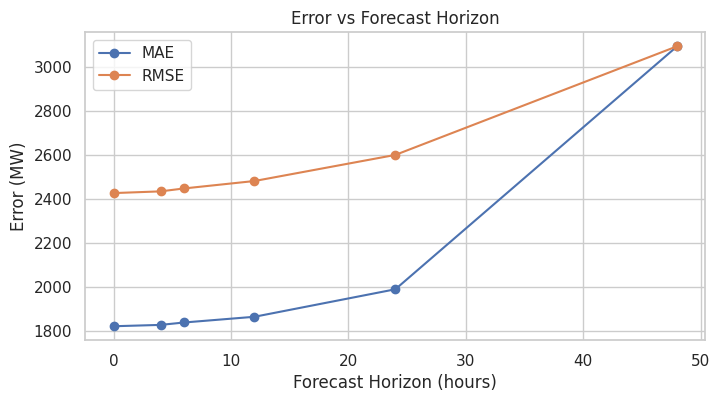

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(horizon_df['horizon'], horizon_df['mae'], marker='o', label='MAE')
plt.plot(horizon_df['horizon'], horizon_df['rmse'], marker='o', label='RMSE')
plt.xlabel('Forecast Horizon (hours)')
plt.ylabel('Error (MW)')
plt.title('Error vs Forecast Horizon')
plt.legend()
plt.show()

## Error vs Time of Day

In [11]:
tod = matched_4h.dropna(subset=['error']).copy()
tod['hour'] = tod['targetTime'].dt.hour
tod['time_bucket'] = pd.cut(
    tod['hour'],
    bins=[-1, 5, 11, 17, 23],
    labels=['00:00-06:00', '06:00-12:00', '12:00-18:00', '18:00-24:00']
)
tod_summary = tod.groupby('time_bucket', observed=False)['error'].agg(['mean', 'median', 'std', 'count'])
tod_summary

,mean,median,std,count
time_bucket,,,,
00:00-06:00,1531.236559,1285.0,2143.012734,186
06:00-12:00,1269.973118,878.5,2344.477058,186
12:00-18:00,959.940860,944.0,1809.514016,186
18:00-24:00,962.822581,581.5,2152.819412,186


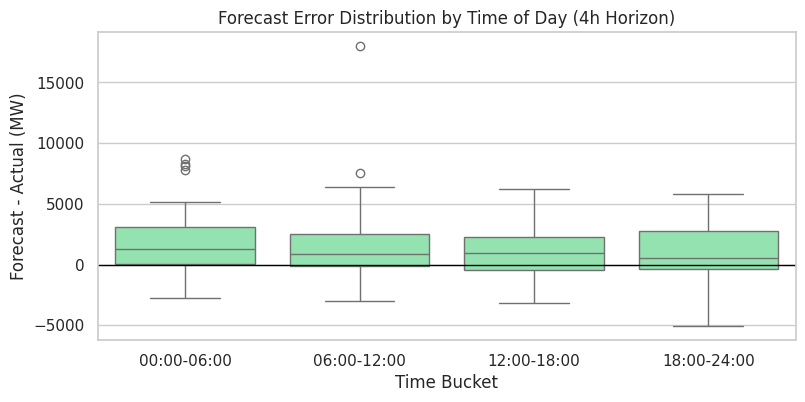

In [12]:
plt.figure(figsize=(9, 4))
sns.boxplot(data=tod, x='time_bucket', y='error', color='#86efac')
plt.axhline(0, color='black', linewidth=1)
plt.title('Forecast Error Distribution by Time of Day (4h Horizon)')
plt.xlabel('Time Bucket')
plt.ylabel('Forecast - Actual (MW)')
plt.show()

## Wind Reliability Analysis (Actual Generation)

In [13]:
actual = matched_4h[['targetTime', 'actualGeneration']].drop_duplicates().dropna()
actual_stats = {
    'min_mw': actual['actualGeneration'].min(),
    'mean_mw': actual['actualGeneration'].mean(),
    'std_mw': actual['actualGeneration'].std(),
    'p50_mw': actual['actualGeneration'].quantile(0.50),
    'p90_available_mw': actual['actualGeneration'].quantile(0.10),
    'p95_available_mw': actual['actualGeneration'].quantile(0.05),
}
pd.Series(actual_stats).round(2)

,0
min_mw,0.00
mean_mw,9848.73
std_mw,3676.02
p50_mw,9863.50
p90_available_mw,5087.90
p95_available_mw,4301.10


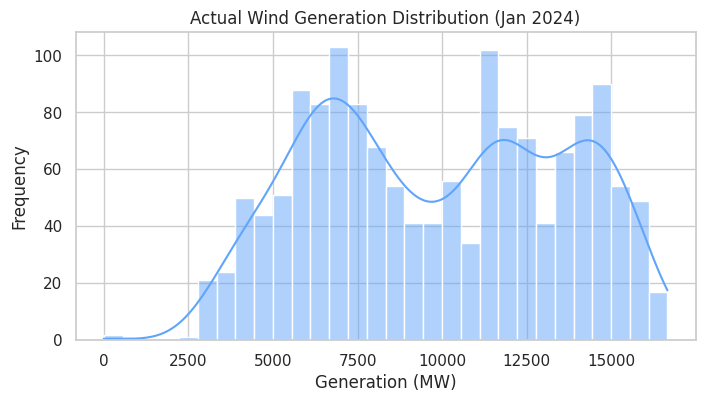

In [14]:
plt.figure(figsize=(8, 4))
sns.histplot(actual['actualGeneration'], bins=30, kde=True, color='#60a5fa')
plt.title('Actual Wind Generation Distribution (Jan 2024)')
plt.xlabel('Generation (MW)')
plt.ylabel('Frequency')
plt.show()

## Reliability Recommendation

A practical planning question is: how much wind generation can we count on with high confidence?

I use an availability framing:
- `p90 available MW` = generation exceeded in 90% of settlement periods (10th percentile).
- `p95 available MW` = generation exceeded in 95% of settlement periods (5th percentile).

Trade-off:
- A higher-confidence metric (p95) is safer but more conservative for operations planning.
- A lower-confidence metric (p90) is less conservative and may suit less risk-averse use-cases.

Recommendation for this exercise: use the p90 available MW as the primary reliability estimate, and track p95 as a stress-case floor.

In [15]:
p90_available_mw = actual['actualGeneration'].quantile(0.10)
p95_available_mw = actual['actualGeneration'].quantile(0.05)

print(f'Recommended reliable wind capacity (p90 basis): {p90_available_mw:,.0f} MW')
print(f'Conservative stress-case floor (p95 basis): {p95_available_mw:,.0f} MW')

Recommended reliable wind capacity (p90 basis): 5,088 MW
Conservative stress-case floor (p95 basis): 4,301 MW


## Final Conclusion

- Forecast error generally increases with longer forecast horizons, as expected.
- Coverage should be checked alongside MAE/RMSE to avoid biased interpretation from missing forecasts.
- For reliability planning in this January 2024 sample, p90 available MW is an evidence-based central recommendation, with p95 available MW as a conservative floor for risk-aware decisions.

This recommendation should be re-estimated on longer history (multi-season, multi-year) before production capacity commitments.